In [1]:
import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
from typing import List, Tuple

# Запуск JVM
jpype.startJVM(classpath=[".."])

# Импорт Java-классов
WorkDistribution = jpype.JClass("utils.graph_coloring.WorkDistribution")
WorkAssignment = jpype.JClass("utils.graph_coloring.WorkDistribution$WorkAssignment")
ContainerPacking = jpype.JClass("utils.graph_coloring.WorkDistribution$ContainerPacking")
ArrayList = jpype.JClass("java.util.ArrayList")

In [2]:
def create_compatibility_matrix(works_data: List[List[bool]]) -> jpype.JArray:
    n = len(works_data)
    matrix = [[True] * n for _ in range(n)]
    
    # Заполняем матрицу совместимости
    for i in range(n):
        for j in range(n):
            # Если работы i и j не могут выполняться одним механизмом
            if any(works_data[i][k] and works_data[j][k] for k in range(len(works_data[i]))):
                matrix[i][j] = False
                matrix[j][i] = False
    
    return jpype.JArray(jpype.JBoolean, 2)(matrix)

def test_work_assignment():
    # Пример из условия
    works_data = [
        [True, False, False, True, False, True, False, False, False, True],  # b1
        [False, True, True, False, False, False, True, False, True, False],  # b2
        [False, True, True, False, True, False, False, True, False, False],  # b3
        [False, False, False, False, False, True, False, False, False, False],  # b4
        [True, False, False, False, True, False, False, False, True, False],  # b5
        [False, False, False, True, False, False, False, True, False, True],  # b6
        [False, False, True, True, False, True, False, False, False, False],  # b7
        [True, False, False, False, False, False, True, False, True, False],  # b8
        [False, False, True, True, False, True, True, False, False, True]   # b9
    ]
    
    compatibility_matrix = create_compatibility_matrix(works_data)
    solver = WorkAssignment(compatibility_matrix)
    result = solver.solve()
    
    print("\nРезультаты распределения работ:")
    print("Назначения механизмов (номер механизма для каждой работы):")
    for i, mechanism in enumerate(result.result):
        print(f"Работа b{i+1}: Механизм {mechanism + 1}")
    print(f"Количество использованных механизмов: {result.numColors}")
    print(f"Время выполнения: {result.executionTime} нс")

def test_container_packing():
    # Пример для задачи о контейнерах
    weights = ArrayList()
    test_weights = [10, 15, 20, 25, 30, 35, 40, 45, 50]
    for w in test_weights:
        weights.add(jpype.JInt(w))  # Явно преобразуем в Java Integer
    
    container_capacity = 70
    solver = ContainerPacking(weights, container_capacity)
    result = solver.solve()
    
    print("\nРезультаты размещения грузов:")
    print(f"Вместимость контейнера: {container_capacity}")
    print("Распределение грузов по контейнерам:")
    for i, container in enumerate(result.result):
        total_weight = sum(test_weights[j] for j in container)
        print(f"Контейнер {i+1}: грузы {[j+1 for j in container]}, общий вес: {total_weight}")
    print(f"Количество использованных контейнеров: {result.numColors}")
    print(f"Время выполнения: {result.executionTime} нс")

def test_performance():
    # Тестирование производительности для разных размеров входных данных
    n_values = [10, 20, 50, 100, 200]
    work_assignment_times = []
    container_packing_times = []
    
    print("\nТестирование производительности:")
    
    for n in n_values:
        print(f"\nРазмер входных данных: {n}")
        
        # Тест задачи о распределении работ
        works_data = [[random.choice([True, False]) for _ in range(n)] for _ in range(n)]
        compatibility_matrix = create_compatibility_matrix(works_data)
        solver = WorkAssignment(compatibility_matrix)
        result = solver.solve()
        work_assignment_times.append(result.executionTime)
        
        # Тест задачи о контейнерах
        weights = ArrayList()
        for _ in range(n):
            weights.add(jpype.JInt(random.randint(1, 100)))  # Явно преобразуем в Java Integer
        solver = ContainerPacking(weights, 100)
        result = solver.solve()
        container_packing_times.append(result.executionTime)
    
    # Построение графиков
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(n_values, work_assignment_times, 'o-')
    plt.xlabel('Количество работ')
    plt.ylabel('Время выполнения (нс)')
    plt.title('Производительность\nраспределения работ')
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(n_values, container_packing_times, 'o-')
    plt.xlabel('Количество грузов')
    plt.ylabel('Время выполнения (нс)')
    plt.title('Производительность\nразмещения грузов')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Вывод результатов в таблицу
    results = pd.DataFrame({
        'n': n_values,
        'work_assignment_time': work_assignment_times,
        'container_packing_time': container_packing_times
    })
    print("\nРезультаты тестирования производительности:")
    print(results.to_string(index=False))

def main():
    # Тестирование примера из условия
    test_work_assignment()
    
    # Тестирование задачи о контейнерах
    test_container_packing()
    
    # Тестирование производительности
    test_performance()


Результаты распределения работ:
Назначения механизмов (номер механизма для каждой работы):
Работа b1: Механизм 2
Работа b2: Механизм 2
Работа b3: Механизм 4
Работа b4: Механизм 4
Работа b5: Механизм 1
Работа b6: Механизм 5
Работа b7: Механизм 3
Работа b8: Механизм 3
Работа b9: Механизм 1
Количество использованных механизмов: 5
Время выполнения: 870600 нс

Результаты размещения грузов:
Вместимость контейнера: 70
Распределение грузов по контейнерам:
Контейнер 1: грузы [1, 7], общий вес: 50
Контейнер 2: грузы [2, 6], общий вес: 50
Контейнер 3: грузы [3, 5], общий вес: 50
Контейнер 4: грузы [4, 8, 9], общий вес: 120
Количество использованных контейнеров: 4
Время выполнения: 134700 нс

Тестирование производительности:

Размер входных данных: 10

Размер входных данных: 20

Размер входных данных: 50

Размер входных данных: 100

Размер входных данных: 200


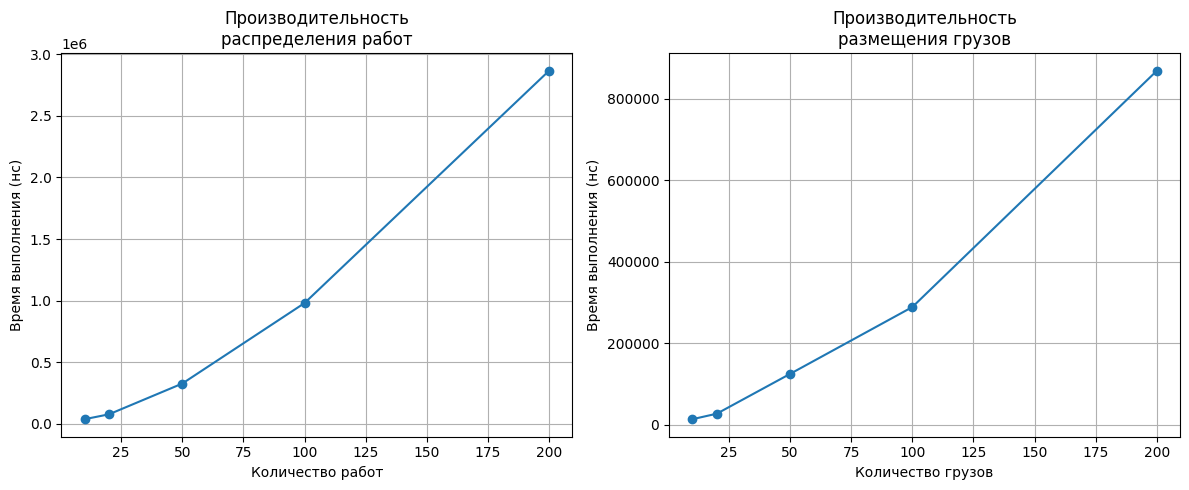


Результаты тестирования производительности:
  n  work_assignment_time  container_packing_time
 10                 37000                   13800
 20                 76700                   27300
 50                326400                  125000
100                979800                  288900
200               2865300                  868400


In [3]:
main() 